# <font color='blue'>Data Science Academy - Machine Learning</font>

# <font color='blue'>Retail Online Shopping Customer Segmentation Analysis RFM + AI with SAP Business Data Cloud</font>


# <font color='blue'>Fabio Ferri - 28/04/2026</font>



### RFM Retail Online Shopping

https://www.kaggle.com/code/hellbuoy/online-retail-k-means-hierarchical-clustering/notebook

In [90]:
# import required libraries for dataframe and visualization

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# import required libraries for clustering
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

## Problem/Business Understanding:

Identify and classify Customer Segmentation with the goal of creating targeted Marketing Campaigns for Customers and Products.

**Customer Segmentation Definition:**

Customer segmentation is the process of dividing the customer base into homogeneous groups based on common characteristics such as purchase behavior, demographics, geography, or psychography. The goal is to enable companies to personalize their marketing strategies, improve customer satisfaction, and increase the efficiency of promotional campaigns.

**RFM Definition:**

RFM (Recency, Frequency, and Monetary Value) is a customer analysis technique that evaluates three main dimensions to measure customer value and behavior:

- **Recency (R):** Time elapsed since the customer's last purchase, indicating how recent their engagement was.
- **Frequency (F):** Number of purchases made by the customer in a determined period, reflecting loyalty and consumption habits.
- **Monetary Value (M):** Total amount spent by the customer, representing their financial contribution to the company.

This analysis helps identify the most valuable customers, segment them, and direct personalized marketing campaigns, optimizing resources and maximizing return on investment.

You must perform the following tasks:
    
1- Handle missing values in the data.

2- Collect a 1% sample of the data to create the K-Means clustering model.

3- Find the best K value for this dataset.

4- Create the K-Means model using the K value found in step 3.

5- Create a Meshgrid for visualization of all clusters.

6- Visualize the centroids.

## Data Acquisition

Identify and obtain relevant datasets for the problem at hand.
Collect data from multiple sources such as databases, APIs, local files, etc.

In [91]:
# Reading the data on which analysis needs to be done

df_retail = pd.read_csv("dados/OnlineRetail.csv", sep=";", encoding="UTF-8", header=0)


## Data Cleaning and Preprocessing:

Assess data quality and handle issues such as missing values, outliers, and errors.
Normalize or standardize data if necessary.

In [92]:
# Display first rows
df_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,"2,55",17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,"3,39",17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,"2,75",17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,"3,39",17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,"3,39",17850.0,United Kingdom


In [93]:
# DataFrame shape
df_retail.shape

(541909, 8)

In [94]:
# DataFrame description
df_retail.describe()

,Quantity,CustomerID
count,541909.000000,406829.000000
mean,9.552250,15287.690570
std,218.081158,1713.600303
min,-80995.000000,12346.000000
25%,1.000000,13953.000000
50%,3.000000,15152.000000
75%,10.000000,16791.000000
max,80995.000000,18287.000000


In [95]:
# DataFrame information
df_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  object 
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


In [96]:
# Shape
df_retail.shape

(541909, 8)

In [97]:
# Check for missing values
df_retail.isnull().values.any()

np.True_

In [98]:
# Remove records with NA values
df_retail = df_retail.dropna()

In [99]:
# Check for missing values
print(df_retail.isna().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [100]:
# Check unique values
df_retail.nunique()

InvoiceNo      22190
StockCode       3684
Description     3896
Quantity         436
InvoiceDate    20460
UnitPrice        620
CustomerID      4372
Country           37
dtype: int64

## Feature Engineering

Perform feature engineering to create new relevant characteristics.

We are going to analysis the Customers based on below 3 factors:
R (Recency): Number of days since last purchase
F (Frequency): Number of tracsactions
M (Monetary): Total amount of transactions (revenue contributed

In [101]:
# New Attribute: Monetary


# This removes dots (thousands) and replaces the comma (decimal) with a dot
from ast import If

# Filter InvoiceNo to keep only rows where it contains only digits (integers)
df_retail = df_retail[df_retail["InvoiceNo"].str.isdigit()]

df_retail["UnitPrice"] = pd.to_numeric(
    df_retail["UnitPrice"].str.replace('.', '').str.replace(',', '.'), 
    errors='coerce'
)

df_retail["UnitPrice"] = df_retail["UnitPrice"].astype(float)


if ((df_retail["Quantity"] != 0 ) & (df_retail["UnitPrice"] != 0)).any():
    df_retail["Amount"] = (df_retail["Quantity"] * df_retail["UnitPrice"])


df_retail["Amount"] = df_retail["Amount"].astype(float)

# Sum by Customer ID 
rfm_m = df_retail.groupby(['CustomerID'])['Amount'].sum().reset_index()
#rfm_m = rfm_m.reset_index()
rfm_m.head()


,CustomerID,Amount
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [102]:
# Check for missing values
print(df_retail.isna().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Amount         0
dtype: int64


In [103]:
df_retail.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom,20.34


In [104]:
# New Attribute: Frequency

rfm_f = df_retail.groupby('CustomerID')['InvoiceNo'].count()
rfm_f = rfm_f.reset_index()
rfm_f.columns = ['CustomerID', 'Frequency']
rfm_f.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


In [105]:
# Merge the two dataframes

rfm = pd.merge(rfm_m, rfm_f, on='CustomerID', how='inner')
rfm.head()

,CustomerID,Amount,Frequency
0,12346.0,77183.60,1
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17


In [106]:
# New Attribute: Recency

# Convert to datetime to proper datatype

df_retail['InvoiceDate'] = pd.to_datetime(df_retail['InvoiceDate'],format='%d/%m/%Y %H:%M')

In [107]:
# Compute the maximum date to know the last transaction date

max_date = max(df_retail['InvoiceDate'])
max_date

Timestamp('2011-12-09 12:50:00')

In [108]:
# Compute the difference between max date and transaction date

df_retail['Diff'] = max_date - df_retail['InvoiceDate']
df_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount,Diff
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373 days 04:24:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373 days 04:24:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00


In [109]:
# Compute last transaction date to get the recency of customers

rfm_p = df_retail.groupby('CustomerID')['Diff'].min()
rfm_p = rfm_p.reset_index()
rfm_p.head()

,CustomerID,Diff
0,12346.0,325 days 02:49:00
1,12347.0,1 days 20:58:00
2,12348.0,74 days 23:37:00
3,12349.0,18 days 02:59:00
4,12350.0,309 days 20:49:00


In [110]:
# Extract days only

rfm_p['Diff'] = rfm_p['Diff'].dt.days
rfm_p.head()

,CustomerID,Diff
0,12346.0,325
1,12347.0,1
2,12348.0,74
3,12349.0,18
4,12350.0,309


In [111]:
# Merge dataframes to get the final RFM dataframe

rfm = pd.merge(rfm, rfm_p, on='CustomerID', how='inner')
rfm.columns = ['CustomerID', 'Amount', 'Frequency', 'Recency']
rfm.head()

,CustomerID,Amount,Frequency,Recency
0,12346.0,77183.60,1,325
1,12347.0,4310.00,182,1
2,12348.0,1797.24,31,74
3,12349.0,1757.55,73,18
4,12350.0,334.40,17,309


## Data Preprocessing

Text(0.5, 0, 'Attributes')

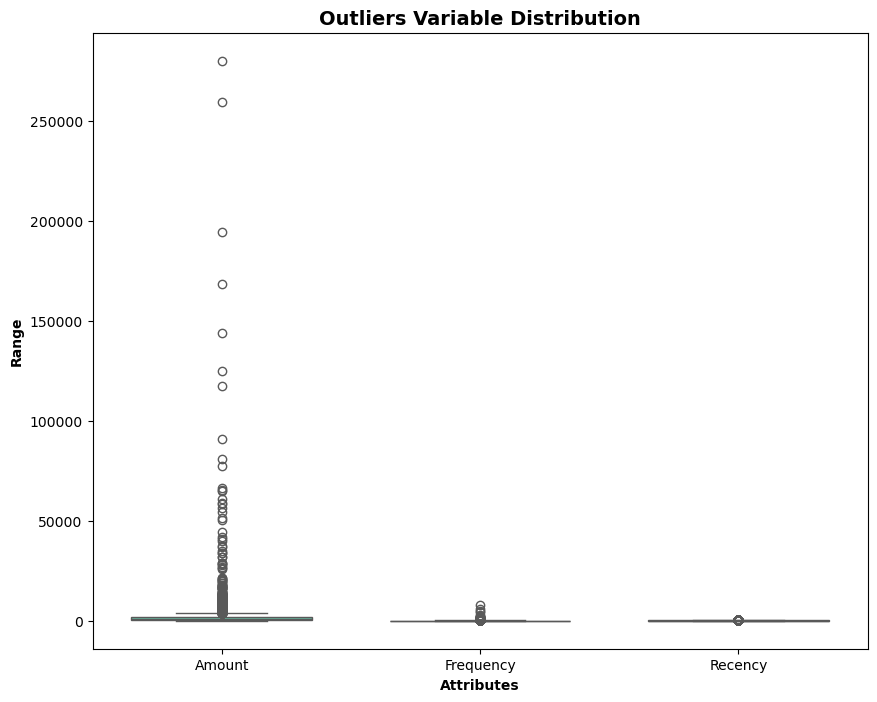

In [112]:
# Outlier analysis for Amount, Frequency, and Recency

attributes = ['Amount','Frequency','Recency']
plt.rcParams['figure.figsize'] = [10,8]
sns.boxplot(data = rfm[attributes], orient="v", palette="Set2" ,whis=1.5,saturation=1, width=0.7)
plt.title("Outliers Variable Distribution", fontsize = 14, fontweight = 'bold')
plt.ylabel("Range", fontweight = 'bold')
plt.xlabel("Attributes", fontweight = 'bold')

In [113]:
# Remove statistical outliers for Amount
Q1 = rfm.Amount.quantile(0.05)
Q3 = rfm.Amount.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Amount >= Q1 - 1.5*IQR) & (rfm.Amount <= Q3 + 1.5*IQR)]

# Removing (statistical) outliers for Recency
Q1 = rfm.Recency.quantile(0.05)
Q3 = rfm.Recency.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Recency >= Q1 - 1.5*IQR) & (rfm.Recency <= Q3 + 1.5*IQR)]

# Removing (statistical) outliers for Frequency
Q1 = rfm.Frequency.quantile(0.05)
Q3 = rfm.Frequency.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Frequency >= Q1 - 1.5*IQR) & (rfm.Frequency <= Q3 + 1.5*IQR)]

Rescaling the Attributes
It is extremely important to rescale the variables so that they have a comparable scale.| There are two common ways of rescaling:

Min-Max scaling
Standardisation (mean-0, sigma-1)
Here, we will use Standardisation Scaling.

In [114]:
rfm[['CustomerID', 'Amount', 'Frequency', 'Recency']]

,CustomerID,Amount,Frequency,Recency
1,12347.0,4310.00,182,1
2,12348.0,1797.24,31,74
3,12349.0,1757.55,73,18
4,12350.0,334.40,17,309
5,12352.0,2506.04,85,35
...,...,...,...,...
4333,18278.0,173.90,9,73
4334,18280.0,180.60,10,277
4335,18281.0,80.82,7,180
4336,18282.0,178.05,12,7


In [115]:
# Rescale the attributes

rfm_df = rfm[['CustomerID','Amount', 'Frequency', 'Recency']]
rfm_df.info()

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform
rfm_df_scaled = scaler.fit_transform(rfm_df)
rfm_df_scaled.shape

<class 'pandas.core.frame.DataFrame'>
Index: 4257 entries, 1 to 4338
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4257 non-null   float64
 1   Amount      4257 non-null   float64
 2   Frequency   4257 non-null   int64  
 3   Recency     4257 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 166.3 KB


(4257, 4)

In [116]:
rfm_df_scaled = pd.DataFrame(rfm_df_scaled)
rfm_df_scaled.columns = ['CustomerID','Amount', 'Frequency', 'Recency']
rfm_df_scaled.head()

,CustomerID,Amount,Frequency,Recency
0,-1.715990,1.645726,1.067832,-0.917872
1,-1.715409,0.262124,-0.460601,-0.189272
2,-1.714828,0.240269,-0.035474,-0.748198
3,-1.714248,-0.543361,-0.602310,2.156221
4,-1.713086,0.652411,0.085991,-0.578524


## Exploratory Data Analysis

Data Exploration:
Perform exploratory analyses to understand data distribution, identify patterns and relationships.
Visualize data using charts and descriptive statistics.

## Data Modeling:

Select the most appropriate machine learning algorithms or data analysis techniques for the problem.
Split data into training, validation, and test sets.
Train and tune the models using the training data.

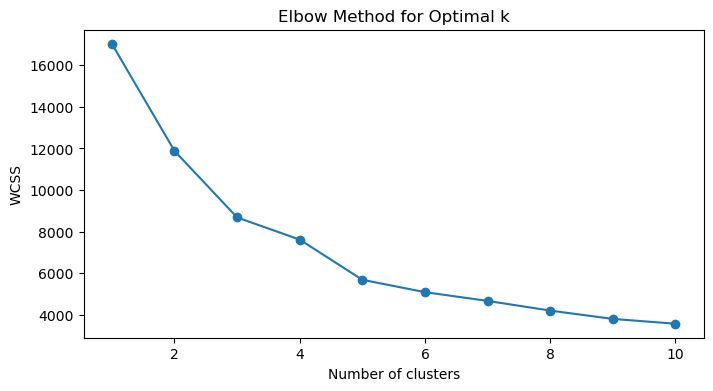

In [117]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


Analysis Summary:
The Graph: Relates the number of clusters (X-axis) to Inertia (Y-axis). Inertia measures the distance of points to the cluster center (lower is better).
The "Elbow": As $k$ increases, inertia decreases. The ideal point is the "bend" in the graph where the sharp decline becomes gradual.
Best Classification: This is the value of $k$ at that bend point. It represents the best balance between compactness (well-grouped data) and simplicity (few groups).

<a id="3.2"></a>

## <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:black; overflow:hidden"><b> Model 1 - Applying K-Means Clustering</b></div>

In [118]:
# Train K-Means model with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_df_scaled)

 
## Analysis Summary - K-Means Model with 5 Clusters

After applying the K-Means algorithm with k=5, we obtained customer segmentation into 5 distinct groups. The distribution of customers by cluster is as follows:

- **Cluster 0:** Customers with low activity and reduced monetary value
- **Cluster 1:** Moderate customers with medium purchase frequency
- **Cluster 2:** Occasional customers with high recency
- **Cluster 3:** Highly active and valuable customers
- **Cluster 4:** Frequent customers with good value potential


<a id="4.1"></a>

## <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:black; overflow:hidden"><b> Model 1 - Pairplot Visualization</b></div>



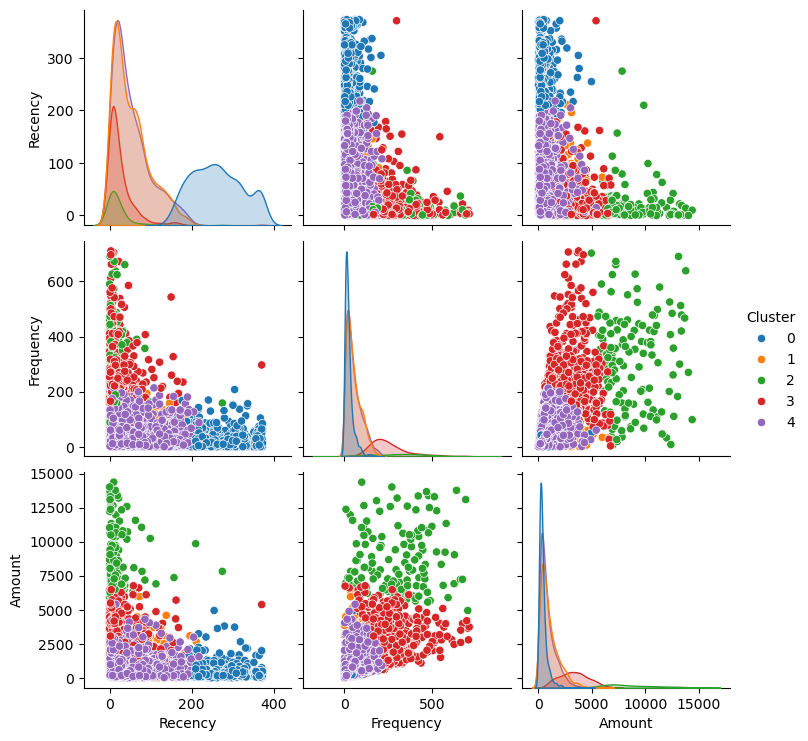

In [119]:
sns.pairplot(rfm, hue='Cluster', vars=['Recency', 'Frequency', 'Amount'], palette='tab10')
plt.show()


<a id="4.2"></a>

## <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:black; overflow:hidden"><b>Model 1 - Cluster Visualization (Scatterplot)</b></div>

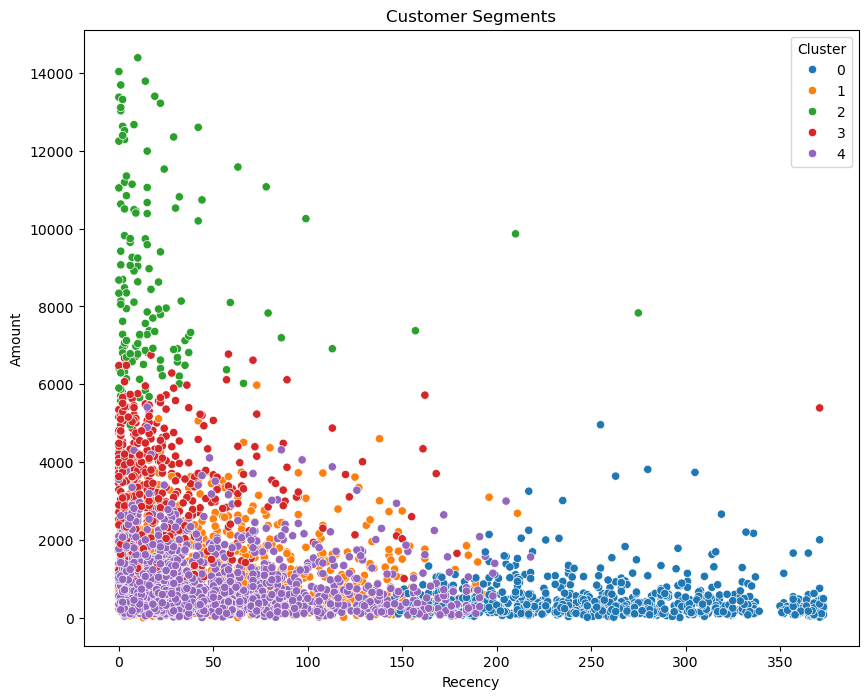

In [120]:
sns.scatterplot(data=rfm, x='Recency', y='Amount', hue='Cluster', palette='tab10')
plt.title('Customer Segments')
plt.show()


<a id="4.3"></a>

## <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:black; overflow:hidden"><b> Modelo 1 - Customer Segments by PCA</b></div>

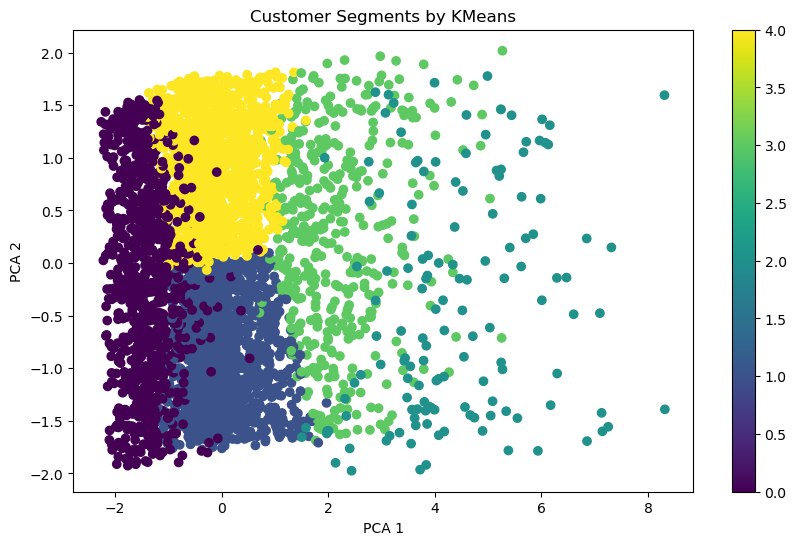

In [121]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(rfm_df_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(components[:, 0], components[:, 1], c=rfm['Cluster'], cmap='viridis')
plt.title('Customer Segments by KMeans')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar()
plt.show()

<a id="3.2"></a>

## <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:black; overflow:hidden"><b> Model 2 - Applying DBSCAN Clustering</b></div>

In [122]:
# Initialize DBSCAN model (first version with default parameters)
dbscan_v1 = DBSCAN()

In [123]:
# Fit the DBSCAN model
dbscan_v1.fit(rfm_df_scaled)

,eps,0.5
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [124]:
# Display cluster labels
dbscan_v1.labels_

array([0, 0, 0, ..., 0, 0, 0], shape=(4257,))

In [125]:
print(set(dbscan_v1.labels_))

{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(-1)}


In [126]:
# Reduce dimensionality using PCA
pca = PCA(n_components = 2).fit(rfm_df_scaled)

In [127]:
# Transform data to 2D using PCA
pca_2d = pca.transform(rfm_df_scaled)

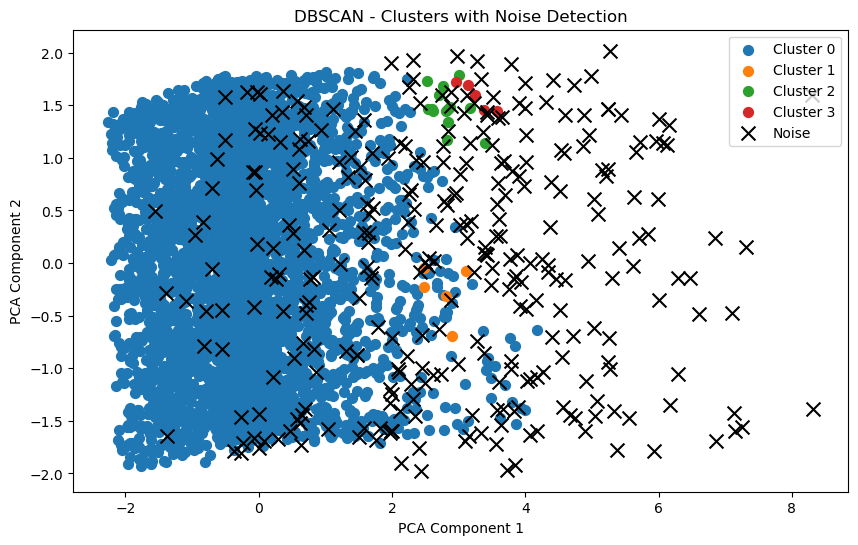

In [128]:
plt.figure(figsize=(10, 6))

labels = set(dbscan_v1.labels_)

for label in labels:
    if label == -1:
        color = 'k'
        marker = 'x'
        size = 100
        name = 'Noise'
    else:
        color = plt.cm.tab10(label)
        marker = 'o'
        size = 50
        name = f'Cluster {label}'
    
    points = pca_2d[dbscan_v1.labels_ == label]
    plt.scatter(points[:,0], points[:,1], c=[color], marker=marker, s=size, label=name)

plt.legend()
plt.title('DBSCAN - Clusters with Noise Detection')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

<a id="4.3"></a>

## <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:black; overflow:hidden"><b> Clustering Analysis Results</b></div>

Both clustering algorithms, K-Means and DBSCAN, were applied to segment customers based on Recency, Frequency, and Monetary Value (RFM) data. K-Means identified 5 distinct clusters, while DBSCAN highlighted customer groups based on data density. The analysis of results revealed valuable insights into customer behavior, enabling the creation of targeted marketing strategies for each identified segment.
The K-Means algorithm was chosen as it provided clearer and more interpretable customer segmentation, facilitating the definition of specific marketing strategies for each identified group.

In [138]:
print(rfm.groupby('Cluster').mean())

           CustomerID       Amount   Frequency     Recency
Cluster                                                   
0        15311.799335   414.409314   24.620843  261.777162
1        13767.855378  1008.149507   51.991279   52.048692
2        14605.255474  8702.135839  309.291971   20.963504
3        15413.694505  3311.149121  254.114286   25.428571
4        16848.648882   839.624998   53.307138   53.036770


<table border="1" cellspacing="0" cellpadding="6">
  <thead>
    <tr>
      <th>Cluster</th>
      <th>Recência (R)</th>
      <th>Frequência (F)</th>
      <th>Monetário (M)</th>
      <th>Perfil do Cliente</th>
      <th>Descrição</th>
      <th>Estratégia Recomendada</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>0</td>
      <td>Média (~55 dias)</td>
      <td>Média (~45)</td>
      <td>Médio (~800)</td>
      <td>Clientes Ativos Moderados</td>
      <td>Clientes com frequência razoável e valor médio, mas sem compras muito recentes.</td>
      <td>Campanhas de incentivo para aumento de frequência e recência (ex: cupons e remarketing).</td>
    </tr>
    <tr>
      <td>1</td>
      <td>Alta (~264 dias)</td>
      <td>Baixa (~24)</td>
      <td>Baixo (~370)</td>
      <td>Clientes Inativos / Perdidos</td>
      <td>Clientes com longo tempo sem compra, baixa frequência e baixo valor monetário.</td>
      <td>Campanhas de reativação ou considerar como churn.</td>
    </tr>
    <tr>
      <td>2</td>
      <td>Baixa (~27 dias)</td>
      <td>Alta (~190)</td>
      <td>Muito Alto (~3048)</td>
      <td>Clientes Premium</td>
      <td>Clientes muito ativos, com alta frequência e alto valor gasto.</td>
      <td>Ofertas exclusivas, programas VIP e retenção prioritária.</td>
    </tr>
    <tr>
      <td>3</td>
      <td>Média (~52 dias)</td>
      <td>Média-Alta (~52)</td>
      <td>Médio (~768)</td>
      <td>Clientes Regulares</td>
      <td>Clientes com comportamento consistente, frequência razoável e valor moderado.</td>
      <td>Upsell e cross-sell para aumentar ticket médio.</td>
    </tr>
    <tr>
      <td>4</td>
      <td>Baixa (~18 dias)</td>
      <td>Muito Alta (~386)</td>
      <td>Muito Alto (~6927)</td>
      <td>Clientes VIP / Top Clientes</td>
      <td>Clientes extremamente engajados, com altíssima frequência e maior valor monetário.</td>
      <td>Atendimento personalizado, benefícios exclusivos e retenção máxima.</td>
    </tr>
  </tbody>
</table>

In [ ]:

rfm["CustomerID"] = rfm["CustomerID"].astype(int)


rfm = rfm.dropna()

df_retail = df_retail.dropna()

# Create df_rfm from rfm dataframe
df_rfm = rfm.copy()

# Save to CSV file
csv_path = 'dados/df_rfm.csv'
df_rfm.to_csv(csv_path, encoding='utf-8', index=False)


# Save to CSV file
csv_path = 'dados/DF_OnlineRetail.csv'
df_retail.to_csv(csv_path, encoding='utf-8', index=False)



print(f"✓ df_rfm criado com sucesso!")
print(f"✓ Arquivo salvo em: {csv_path}")
print(f"\nDimensões: {df_rfm.shape}")
print(f"\nPrimeiras linhas:\n{df_rfm.head()}")

<div style="font-family: Arial, sans-serif; line-height: 1.6;">

  <h2 style="color:#0a6ed1;">📊 Executive Dashboard Overview</h2>

  <p>
    To transform data into strategic decisions, we developed a set of analytics dashboards
    integrated with <b>SAP Analytics Cloud (SAC)</b>, focusing on intelligent customer segmentation.
  </p>

  <p>
    These dashboards consolidate complex customer behavior information into simple,
    intuitive, and action-oriented visualizations, enabling managers to have a clear and immediate business view.
  </p>

  <h3 style="color:#0854a0;">🔍 What You Will See Next</h3>

  <ul>
    <li>📈 <b>Consolidated customer view</b> with key performance indicators (KPIs)</li>
    <li>🧠 <b>Automatic AI-powered segmentation</b> using RFM and clustering algorithms</li>
    <li>💰 <b>Revenue analysis by customer profile</b></li>
    <li>⚠️ <b>Identification of at-risk customers (churn risk)</b></li>
    <li>🎯 <b>Foundation for targeted strategic actions</b></li>
  </ul>

  <h3 style="color:#0854a0;">🖥️ Customer Segmentation Dashboard</h3>

  <p>
    The image below presents the dashboard developed in SAC, where it is possible to explore customer segments,
    analyze purchase behavior, and identify business opportunities in a visual and interactive way.
  </p>

  <p style="color:gray; font-size: 13px;">
    (Inserir aqui a imagem do Dashboard SAC gerado)
  </p>

  <hr>

  <h3 style="color:#0854a0;">🔄 Arquitetura e Fluxo de Dados</h3>

  <p>
    Beyond visualization, the project was structured on a modern and scalable architecture,
    ensuring governance, performance, and integration with the SAP ecosystem.
  </p>

  <p>
    O fluxo de dados integra <b>Databricks</b>, <b>SAP Business Data Cloud</b> e <b>SAP Analytics Cloud</b>,
    enabling advanced processing, analytical modeling, and near-real-time consumption.
  </p>

  <p style="color:gray; font-size: 13px;">

     
  </p>

  <hr>

</div>

![Dashboard](./images/Segmentação de clientes RFM na SAC.png)

![Segmentação de clientes RFM na SAC.png](<attachment:Segmentação de clientes RFM na SAC.png>)
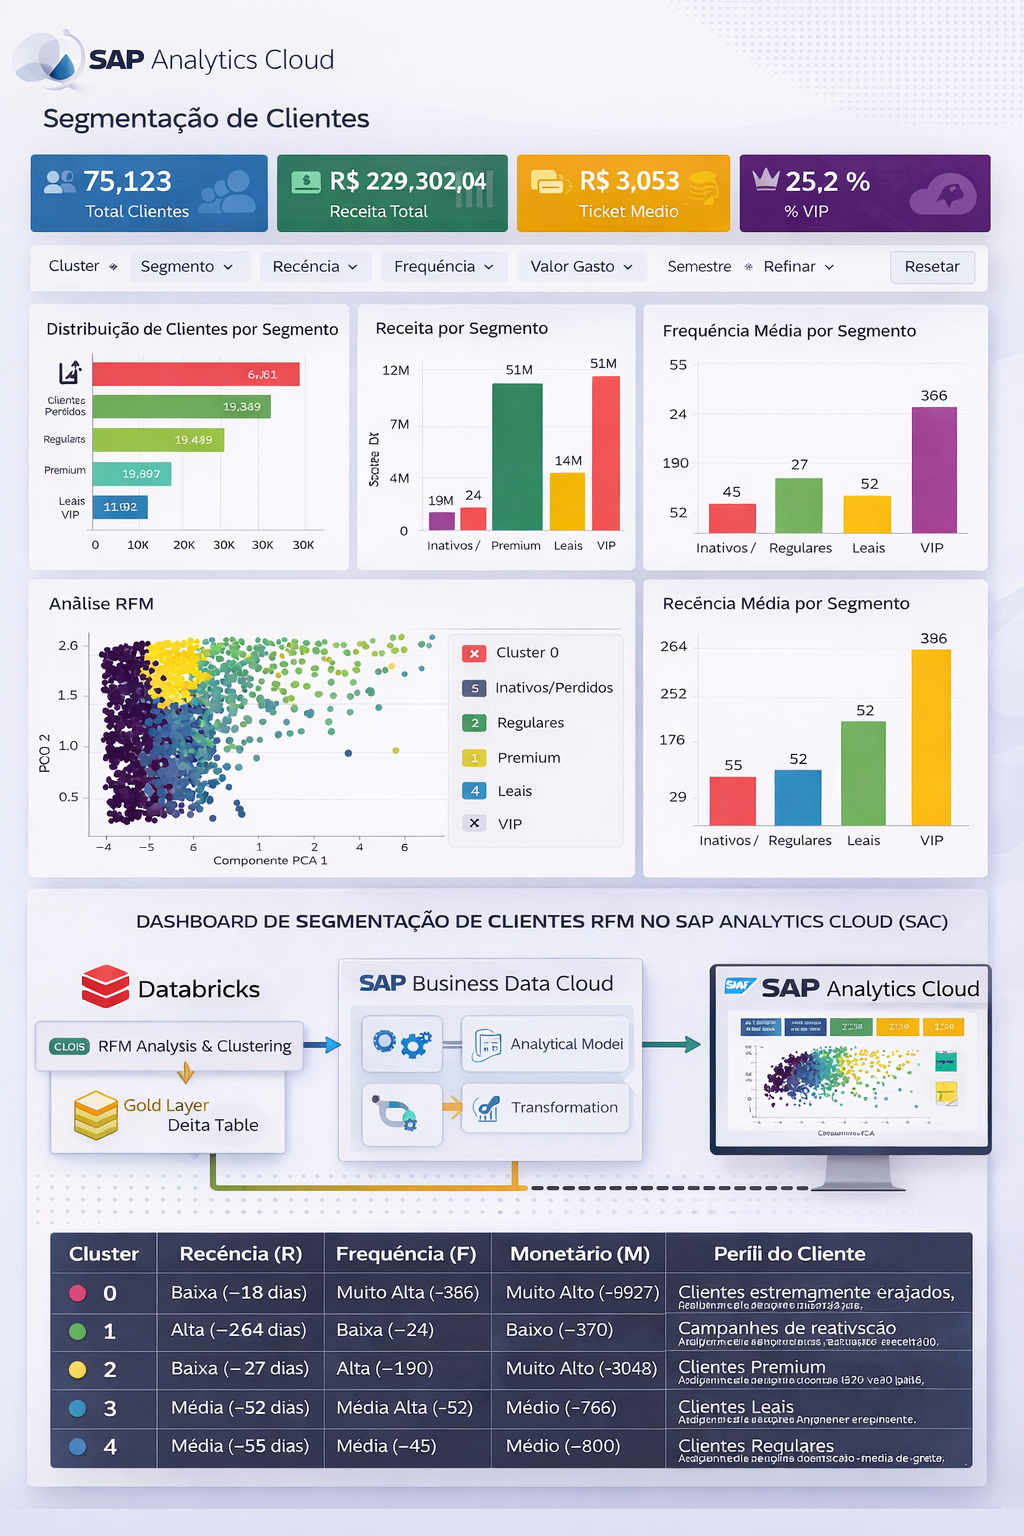